## About
this way the autoencoder works somehow but the shape it learned is poor quality and it just does not fit even though it finds outliers similarly to linear model or ML algorithms

In [86]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

In [87]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.plotting_styles import apply_global_style

In [88]:
from src.load_sam_data import load_dataset
from src.autoencoders import drop_empty_histograms
from src.autoencoders import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

..\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [90]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [91]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [92]:
pt = dataset[34]

# to get the actual lenght
pt_len = len(pt)
print(type(pt))
pt = torch.tensor(pt.reshape(1, 1, pt_len))
encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=3),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

print(f"The encoded data shape: {encoder(pt).shape}")

<class 'numpy.ndarray'>
The encoded data shape: torch.Size([1, 1, 24])


In [93]:
pt = dataset_no_outs[0].reshape(1,1,96)

encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=3),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid())

decoder = nn.Sequential(
            nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.ConvTranspose1d(1, 1, kernel_size=2, stride=1),
            nn.BatchNorm1d(1),
            nn.Sigmoid())

decoder(encoder(pt)).shape

torch.Size([1, 1, 96])

In [94]:
class AE_old(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=3),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.ConvTranspose1d(1, 1, kernel_size=2, stride=1),
            nn.BatchNorm1d(1),
            nn.Sigmoid())
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [95]:
import torch
import torch.nn as nn

class Residual1D(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
        )
        self.act = nn.LeakyReLU(0.1, inplace=True)
    def forward(self, x):
        return self.act(x + self.block(x))

class AE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # ---- Encoder ----
        self.enc = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=2, padding=1),   # 96 → 48
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(16),

            nn.Conv1d(16, 32, 3, stride=2, padding=1), # 48 → 24
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(32),

            nn.Conv1d(32, latent_dim, 3, stride=2, padding=1), # 24 → 12
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(0.1, inplace=True),
        )

        # ---- Decoder ----
        self.dec = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 32, 4, stride=2, padding=1), # 12 → 24
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(32),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1), # 24 → 48
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(16),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1), # 48 → 96
            nn.Sigmoid()  # Since data is [0,1]
        )

    def forward(self, x):
        z = self.enc(x)
        out = self.dec(z)
        return out

In [ ]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = AE_old()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.00005)

In [115]:
from src.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=40, dataloader=train_loader, model=ae_conv, val_loader=test_loader, optimizer=optimizer, criterion=criterion)

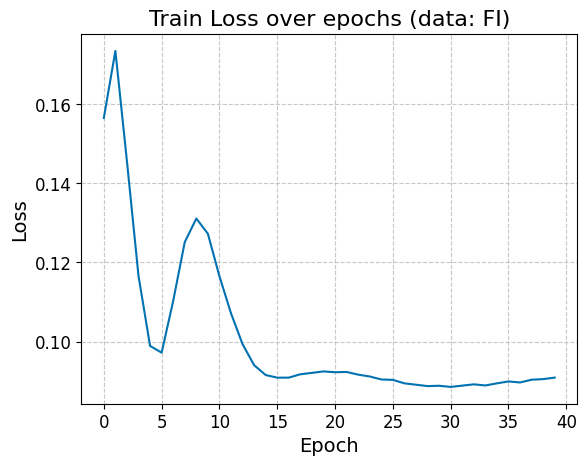

In [116]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

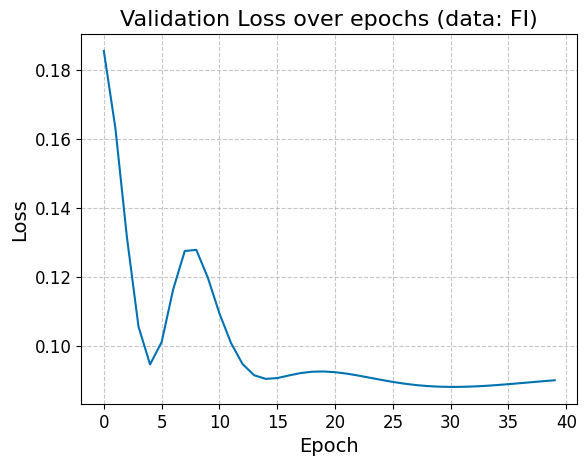

In [117]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [118]:
full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

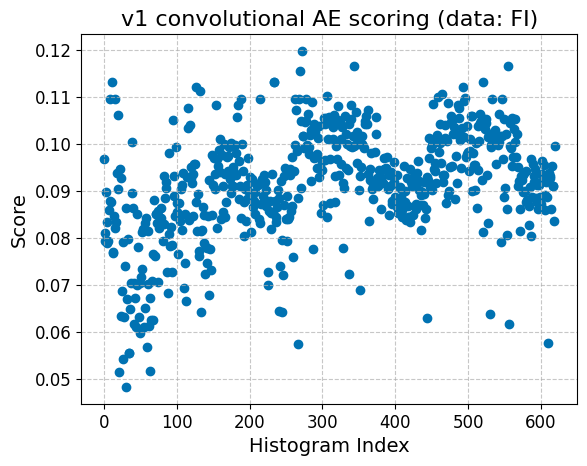

In [119]:
apply_global_style()
plt.title("v1 convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pred = ae_conv(pt.reshape(1,1,96))
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

plt.scatter(range(len(score)), score)
plt.show()

In [ ]:
outliers = np.where(np.array(score) > 0.14)
outliers

(array([  8,  11,  15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546,
        555]),)

In [104]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.reshape(1, 1, 96)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


In [ ]:
preds[9]

array([0.19479758, 0.13571848, 0.13905594, 0.17616089, 0.12266718,
       0.17142385, 0.19075266, 0.14131995, 0.2395936 , 0.27622238,
       0.32677683, 0.29661056, 0.30811903, 0.41084763, 0.4893541 ,
       0.44472426, 0.52611965, 0.54792035, 0.6650478 , 0.637911  ,
       0.55937284, 0.5959137 , 0.6974178 , 0.78204745, 0.8739407 ,
       0.7438217 , 0.8586837 , 0.8226631 , 0.7268582 , 0.7353352 ,
       0.8324137 , 0.9343922 , 0.96904325, 0.8445139 , 0.9425989 ,
       0.9160186 , 0.8422442 , 0.8348684 , 0.9097295 , 0.9787846 ,
       0.9901782 , 0.9002708 , 0.9691012 , 0.9375704 , 0.9027719 ,
       0.85999304, 0.9286933 , 0.97947204, 0.9902581 , 0.8997657 ,
       0.96224284, 0.915743  , 0.88748044, 0.82945746, 0.9162103 ,
       0.9415237 , 0.9639976 , 0.7880838 , 0.88581944, 0.73923355,
       0.72830373, 0.67643684, 0.75908065, 0.53429383, 0.45675173,
       0.39939407, 0.45811635, 0.4539463 , 0.25455245, 0.27555835,
       0.25828877, 0.28606266, 0.1258111 , 0.1516547 , 0.11508

In [ ]:
preds[6]

array([0.19123794, 0.13294053, 0.13191508, 0.1866722 , 0.08965193,
       0.15381014, 0.12331412, 0.13677123, 0.14795116, 0.15868144,
       0.1421806 , 0.17114906, 0.16198345, 0.2577936 , 0.2586992 ,
       0.16895765, 0.45463437, 0.42908946, 0.5335032 , 0.49876767,
       0.4529972 , 0.5060207 , 0.6006133 , 0.62719643, 0.74740905,
       0.66829515, 0.7589784 , 0.7354684 , 0.6369796 , 0.6631302 ,
       0.7698406 , 0.8715407 , 0.93132293, 0.79192716, 0.9049056 ,
       0.868068  , 0.7847711 , 0.78130364, 0.8752639 , 0.95628464,
       0.9769384 , 0.85692716, 0.94974107, 0.9020064 , 0.8495448 ,
       0.8129687 , 0.90356946, 0.95120573, 0.9729226 , 0.847268  ,
       0.9310317 , 0.8557334 , 0.80701166, 0.7548619 , 0.8633413 ,
       0.8378053 , 0.8921963 , 0.68007785, 0.7680466 , 0.6418067 ,
       0.6071615 , 0.5759904 , 0.6754225 , 0.46333542, 0.29406655,
       0.2869192 , 0.24680088, 0.3063583 , 0.14630696, 0.18963175,
       0.17556053, 0.20789069, 0.09314682, 0.12646103, 0.09790

tensor(0.1045)


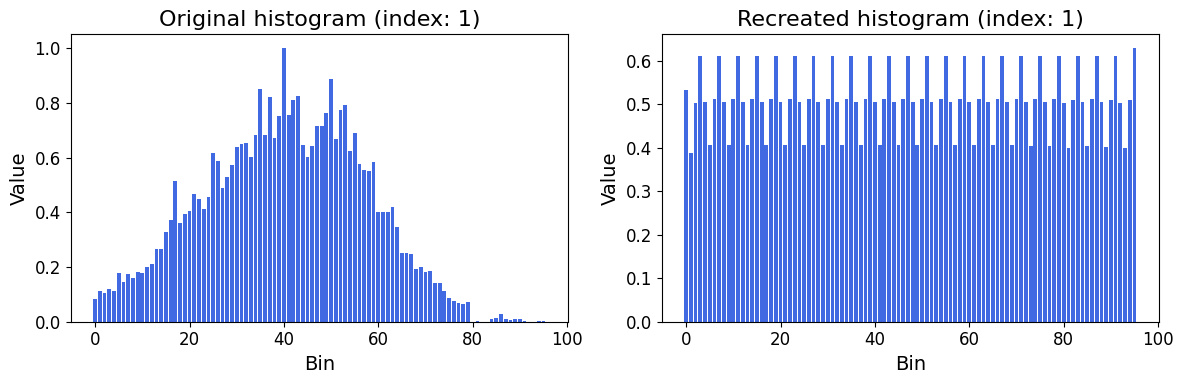

In [113]:
idx = 1

ae_conv.eval()
pred = ae_conv(full_dataset[idx].reshape(1, 1, 96)).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
plt.tight_layout()
print(loss)
plt.show()

In [110]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [233, 344, 555, 8, 15, 188, 214, 263, 268, 533]
lowest scores [287, 530, 328]


In [ ]:
#torch.save(ae, 'functional_ae_conv_2.pth')

In [ ]:
(dataset[0] == dataset[0]).all()

np.True_

In [ ]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(dataset):
        data = data.unsqueeze(0)     
        pred = ae(data).numpy()
         
        for p in preds:
            if (pred == p).all():
                break
        else:
            preds.append(pred)
        
        if idx % 100 == 0: 
            print(idx)

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'